# **Main code**

In [ ]:
!pip install stable_baselines3
!pip install shimmy
import yfinance as yf #this is for getting dataset
import pandas as pd #for dealing with dataset
from datetime import datetime, timedelta #datetime combines date and time info
#and timedelta is used for calculating difference between dates and times
from sklearn.preprocessing import MinMaxScaler
import pickle
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from gymnasium import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv
import gym

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 184.5/184.5 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 86.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 75.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 38.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 76.6 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstallin

# Getting Data

In [ ]:
tickers = ["AAPL", "MSFT", "GOOGL", "AMZN", "TSLA", "META", "NVDA", "NFLX", "BRK-B", "JNJ"]

end_date = datetime.today() #present time
start_date = end_date - timedelta(days=2 * 365) #two years from current time

data_center = {} #it will store dataset as company name as key and the data as value

for ticker in tickers:
    print(f"Downloading data set for {ticker}...")
    data_center[ticker] = yf.download(ticker, start=start_date, end=end_date)

temp_data_set = pd.concat(data_center, axis=1) #concatinating all the dataset into column wise file

print("\nColumns in the DataFrame ('MultiIndex')\n\n", temp_data_set.columns)

# Reset the index to include the date column
temp_data_set.reset_index(inplace=True)

# Flattening the MultiIndex columns so we can melt it
temp_data_set.columns = ['_'.join(filter(None, col)) if isinstance(col, tuple) else col for col in temp_data_set.columns]

# Renaming the Date column in the temp_dats_set
temp_data_set.rename(columns={"Date_": "Date"}, inplace=True)

print("\nColumns after flattening\n\n")
print(temp_data_set.columns)

# Reshape the data to long format
final_data_set = temp_data_set.melt(id_vars=["Date"], var_name="Ticker_Attribute", value_name="Value")

print("\nPrinting final dataset\n\n", final_data_set)

# Splitting the Ticker_Attribute column into separate columns for Attribute and Ticker
final_data_set[['Attribute', 'Ticker']] = final_data_set['Ticker_Attribute'].str.rsplit('_', n=2, expand=True).iloc[:, 1:]
#n = 2 is used to split the string from right to avoid ticker spliting

final_data_set.drop(columns=['Ticker_Attribute'], inplace=True)

final_data_set.to_csv("data_set_of_ten_companies_of_last_two_years.csv", index=False)
print("data_set_of_ten_companies_of_last_two_years.csv has been downloaded.")


[*********************100%***********************]  1 of 1 completed


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


[*********************100%***********************]  1 of 1 completed



Columns in the DataFrame ('MultiIndex')

 MultiIndex([( 'AAPL',  'Close',  'AAPL'),
            ( 'AAPL',   'High',  'AAPL'),
            ( 'AAPL',    'Low',  'AAPL'),
            ( 'AAPL',   'Open',  'AAPL'),
            ( 'AAPL', 'Volume',  'AAPL'),
            ( 'MSFT',  'Close',  'MSFT'),
            ( 'MSFT',   'High',  'MSFT'),
            ( 'MSFT',    'Low',  'MSFT'),
            ( 'MSFT',   'Open',  'MSFT'),
            ( 'MSFT', 'Volume',  'MSFT'),
            ('GOOGL',  'Close', 'GOOGL'),
            ('GOOGL',   'High', 'GOOGL'),
            ('GOOGL',    'Low', 'GOOGL'),
            ('GOOGL',   'Open', 'GOOGL'),
            ('GOOGL', 'Volume', 'GOOGL'),
            ( 'AMZN',  'Close',  'AMZN'),
            ( 'AMZN',   'High',  'AMZN'),
            ( 'AMZN',    'Low',  'AMZN'),
            ( 'AMZN',   'Open',  'AMZN'),
            ( 'AMZN', 'Volume',  'AMZN'),
            ( 'TSLA',  'Close',  'TSLA'),
            ( 'TSLA',   'High',  'TSLA'),
            ( 'TSLA',    'Low',  

# Preprocessing and EDA

In [ ]:
df = pd.read_csv(r'data_set_of_ten_companies_of_last_two_years.csv')
print(df.head(10))
print("Missing values before cleaning:\n", df.isnull().sum())


         Date       Value Attribute Ticker
0  2023-04-04  163.976334     Close   AAPL
1  2023-04-05  162.125015     Close   AAPL
2  2023-04-06  163.016052     Close   AAPL
3  2023-04-10  160.412292     Close   AAPL
4  2023-04-11  159.194580     Close   AAPL
5  2023-04-12  158.501556     Close   AAPL
6  2023-04-13  163.907013     Close   AAPL
7  2023-04-14  163.560547     Close   AAPL
8  2023-04-17  163.580338     Close   AAPL
9  2023-04-18  164.807953     Close   AAPL
Missing values before cleaning:
 Date         0
Value        0
Attribute    0
Ticker       0
dtype: int64


In [ ]:
# Function to calculate technical indicators
def add_technical_indicators(df):
    window = 14  # Standard window size for RSI and moving averages

    # Simple Moving Average (SMA)
    df['SMA'] = df.groupby('Ticker')['Value'].transform(lambda x: x.rolling(window).mean())

    # Exponential Moving Average (EMA)
    df['EMA'] = df.groupby('Ticker')['Value'].transform(lambda x: x.ewm(span=window, adjust=False).mean())

    # Relative Strength Index (RSI)
    def compute_rsi(series, window=14):
        delta = series.diff()
        gain = (delta.where(delta > 0, 0)).rolling(window=window).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window=window).mean()
        rs = gain / loss
        return 100 - (100 / (1 + rs))

    df['RSI'] = df.groupby('Ticker')['Value'].transform(lambda x: compute_rsi(x, window))

    # MACD (12, 26, 9)
    ema12 = df.groupby('Ticker')['Value'].transform(lambda x: x.ewm(span=12, adjust=False).mean())
    ema26 = df.groupby('Ticker')['Value'].transform(lambda x: x.ewm(span=26, adjust=False).mean())
    df['MACD'] = ema12 - ema26
    df['Signal_Line'] = df.groupby('Ticker')['MACD'].transform(lambda x: x.ewm(span=9, adjust=False).mean())

    # Bollinger Bands (20-period SMA with ±2 standard deviations)
    df['BB_Middle'] = df.groupby('Ticker')['Value'].transform(lambda x: x.rolling(20).mean())
    df['BB_Upper'] = df['BB_Middle'] + 2 * df.groupby('Ticker')['Value'].transform(lambda x: x.rolling(20).std())
    df['BB_Lower'] = df['BB_Middle'] - 2 * df.groupby('Ticker')['Value'].transform(lambda x: x.rolling(20).std())

    return df

# Apply technical indicators
df = add_technical_indicators(df)

# Check the new columns
print(df.columns)

print(f"\n\n{df.head()}\n\n{df.tail()}\n")


Index(['Date', 'Value', 'Attribute', 'Ticker', 'SMA', 'EMA', 'RSI', 'MACD',
       'Signal_Line', 'BB_Middle', 'BB_Upper', 'BB_Lower'],
      dtype='object')


         Date       Value Attribute Ticker  SMA         EMA  RSI      MACD  \
0  2023-04-04  163.976334     Close   AAPL  NaN  163.976334  NaN  0.000000   
1  2023-04-05  162.125015     Close   AAPL  NaN  163.729491  NaN -0.147684   
2  2023-04-06  163.016052     Close   AAPL  NaN  163.634366  NaN -0.190627   
3  2023-04-10  160.412292     Close   AAPL  NaN  163.204756  NaN -0.429807   
4  2023-04-11  159.194580     Close   AAPL  NaN  162.670066  NaN -0.709441   

   Signal_Line  BB_Middle  BB_Upper  BB_Lower  
0     0.000000        NaN       NaN       NaN  
1    -0.029537        NaN       NaN       NaN  
2    -0.061755        NaN       NaN       NaN  
3    -0.135365        NaN       NaN       NaN  
4    -0.250180        NaN       NaN       NaN  

             Date       Value Attribute Ticker           SMA           EMA  \
2504

In [ ]:
# Select features to normalize
features_to_normalize = ['Value', 'SMA', 'EMA', 'RSI', 'MACD', 'Signal_Line', 'BB_Middle', 'BB_Upper', 'BB_Lower']

# Apply Min-Max scaling
scaler = MinMaxScaler()
df[features_to_normalize] = scaler.fit_transform(df[features_to_normalize])

# Verify normalization
print(f"{df.head()}\n\n{df.tail()}")


         Date         Value Attribute Ticker  SMA           EMA  RSI  \
0  2023-04-04  8.923659e-08     Close   AAPL  NaN  1.944932e-07  NaN   
1  2023-04-05  8.803748e-08     Close   AAPL  NaN  1.941426e-07  NaN   
2  2023-04-06  8.861461e-08     Close   AAPL  NaN  1.940075e-07  NaN   
3  2023-04-10  8.692814e-08     Close   AAPL  NaN  1.933973e-07  NaN   
4  2023-04-11  8.613942e-08     Close   AAPL  NaN  1.926380e-07  NaN   

       MACD  Signal_Line  BB_Middle  BB_Upper  BB_Lower  
0  0.261926     0.269497        NaN       NaN       NaN  
1  0.261926     0.269497        NaN       NaN       NaN  
2  0.261926     0.269497        NaN       NaN       NaN  
3  0.261926     0.269497        NaN       NaN       NaN  
4  0.261926     0.269497        NaN       NaN       NaN  

             Date     Value Attribute Ticker       SMA       EMA       RSI  \
25045  2025-03-27  0.004374    Volume    JNJ  0.012225  0.012002  0.456622   
25046  2025-03-28  0.003731    Volume    JNJ  0.011032  0.0114

# Saving the preprocessed data


In [ ]:
    df.to_csv("processed_stock_data.csv", index=False)
    print("processed_stock_data.csv has been saved.")


processed_stock_data.csv has been saved.


# **Implementing Rienforcement Learning**

Final Training code

In [ ]:
import pandas as pd
import numpy as np
import gymnasium as gym
from gymnasium import spaces
from sklearn.model_selection import train_test_split
from stable_baselines3 import PPO

# Load processed stock data
df = pd.read_csv("processed_stock_data.csv")

# Convert Date to datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Sort by Date and Ticker
df = df.sort_values(by=['Ticker', 'Date']).reset_index(drop=True)

# Handle missing values
df.ffill(inplace=True)
df.bfill(inplace=True)

train_data, test_data = train_test_split(df, test_size=0.2, shuffle=False)

class StockTradingEnv(gym.Env):
    def __init__(self, data):
        super(StockTradingEnv, self).__init__()
        self.data = data
        self.current_step = 0
        self.max_steps = len(data) - 1

        # Action Space: Buy, Sell, Hold (3 Discrete Actions)
        self.action_space = spaces.Discrete(3)

        # Observation Space: 9 Normalized Features
        self.observation_space = spaces.Box(low=0, high=1, shape=(9,), dtype=np.float32)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_step = 0
        return self._get_observation(), {}

    def _get_observation(self):
        obs = self.data.iloc[self.current_step][['Value', 'SMA', 'EMA', 'RSI', 'MACD', 'Signal_Line', 'BB_Middle', 'BB_Upper', 'BB_Lower']]
        return np.array(obs, dtype=np.float32)

    #reward system begins
    def step(self, action):
        self.current_step += 1

        if self.current_step >= self.max_steps:
            done = True
            reward = 0
        else:
            done = False
            future_price = self.data.iloc[self.current_step]['Value']
            current_price = self.data.iloc[self.current_step - 1]['Value']

            if np.isnan(future_price) or np.isnan(current_price):
                reward = 0
            else:
                reward = (future_price - current_price) if action == 0 else (current_price - future_price)

        return self._get_observation(), reward, done, False, {}

# Create training environment
train_env = StockTradingEnv(train_data)
train_env = gym.wrappers.FlattenObservation(train_env)

# Train PPO Model
model = PPO("MlpPolicy", train_env, verbose=1, tensorboard_log="./ppo_stock_trading/", learning_rate=0.0003, clip_range=0.2)
model.learn(total_timesteps=10000)

# Save the trained model
model.save("ppo_stock_trading_model")

# Load model for testing
test_env = StockTradingEnv(test_data)
test_env = gym.wrappers.FlattenObservation(test_env)
model = PPO.load("ppo_stock_trading_model")

# Evaluate model
obs, _ = test_env.reset()
done = False
predictions = []
while not done:
    action, _ = model.predict(obs)
    obs, reward, done, _, _ = test_env.step(action)
    predictions.append(action)

# Print predictions
print("Predicted Actions (0=Buy, 1=Sell, 2=Hold):", predictions)


Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Logging to ./ppo_stock_trading/PPO_3
-----------------------------
| time/              |      |
|    fps             | 409  |
|    iterations      | 1    |
|    time_elapsed    | 5    |
|    total_timesteps | 2048 |
-----------------------------
-----------------------------------------
| time/                   |             |
|    fps                  | 353         |
|    iterations           | 2           |
|    time_elapsed         | 11          |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.011603718 |
|    clip_fraction        | 0.0581      |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.09       |
|    explained_variance   | -0.0329     |
|    learning_rate        | 0.0003      |
|    loss                 | -0.029      |
|    n_updates            | 10          |
|    policy_gradient_loss | -

In [ ]:
import numpy as np

# Store rewards for performance metrics calculation
rewards = []
actions = []
portfolio_values = [100000]  # Assume an initial portfolio value

obs, _ = test_env.reset()
done = False

while not done:
    action, _ = model.predict(obs)
    obs, reward, done, _, _ = test_env.step(action)

    rewards.append(reward)
    actions.append(action)
    portfolio_values.append(portfolio_values[-1] + reward)  # Simulated portfolio change

# Convert to numpy array
rewards = np.array(rewards)

# Calculate Win Rate
win_trades = np.sum(rewards > 0)
total_trades = len(rewards)
win_rate = win_trades / total_trades if total_trades > 0 else 0

# Calculate Sharpe Ratio
returns = np.diff(portfolio_values) / portfolio_values[:-1]
sharpe_ratio = np.mean(returns) / np.std(returns) if np.std(returns) != 0 else 0

# Calculate Max Drawdown
peak = np.maximum.accumulate(portfolio_values)
drawdowns = (portfolio_values - peak) / peak
max_drawdown = np.min(drawdowns)

# Display results
print(f"Win Rate: {win_rate * 100:.2f}%")
print(f"Sharpe Ratio: {sharpe_ratio:.2f}")
print(f"Max Drawdown: {max_drawdown * 100:.2f}%")


Win Rate: 65.32%
Sharpe Ratio: 0.33
Max Drawdown: -0.00%


# Visual Representation


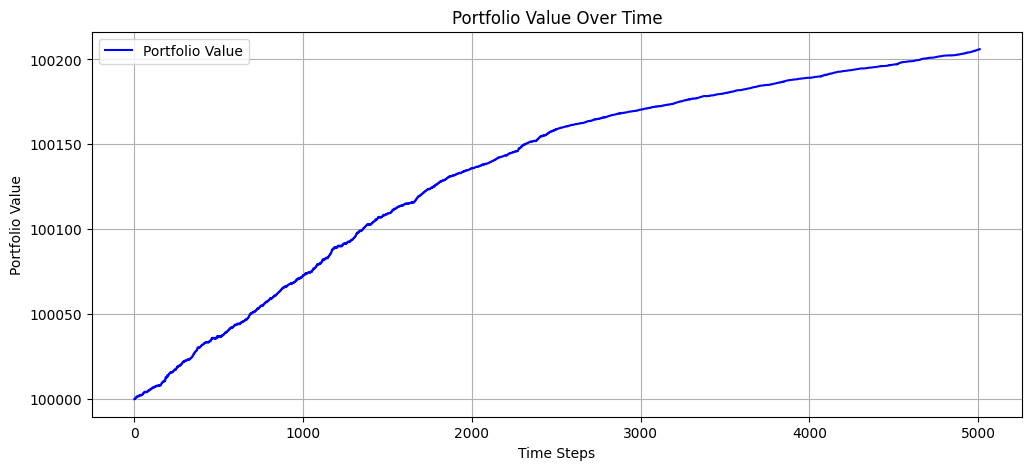

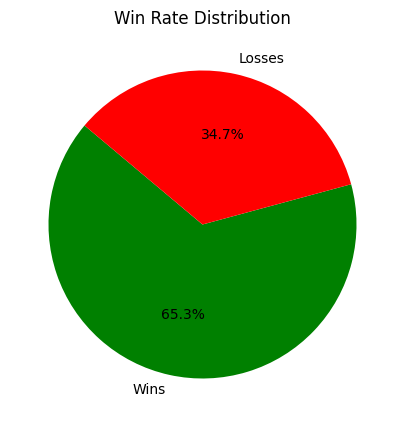

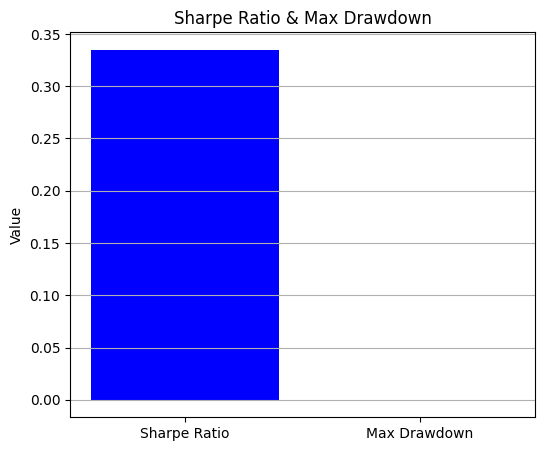

In [ ]:
import matplotlib.pyplot as plt

# Convert lists to numpy arrays
portfolio_values = np.array(portfolio_values)
rewards = np.array(rewards)

# Plot Portfolio Value Over Time
plt.figure(figsize=(12, 5))
plt.plot(portfolio_values, label="Portfolio Value", color='blue')
plt.xlabel("Time Steps")
plt.ylabel("Portfolio Value")
plt.title("Portfolio Value Over Time")
plt.legend()
plt.grid()
plt.show()

# Win Rate Pie Chart
plt.figure(figsize=(5, 5))
labels = ['Wins', 'Losses']
sizes = [win_trades, total_trades - win_trades]
colors = ['green', 'red']
plt.pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors, startangle=140)
plt.title("Win Rate Distribution")
plt.show()

# Sharpe Ratio & Max Drawdown Bar Chart
plt.figure(figsize=(6, 5))
metrics = ['Sharpe Ratio', 'Max Drawdown']
values = [sharpe_ratio, max_drawdown]
plt.bar(metrics, values, color=['blue', 'orange'])
plt.ylabel("Value")
plt.title("Sharpe Ratio & Max Drawdown")
plt.grid(axis='y')
plt.show()


In [ ]:
import json

# Store predictions in a structured format
predictions_data = []

# Reset environment for evaluation
obs, _ = test_env.reset()
done = False
step = 0

while not done:
    action, _ = model.predict(obs)
    obs, reward, done, _, _ = test_env.step(action)

    # Get stock name and price for the current step
    stock_name = test_data.iloc[step]['Ticker']
    stock_price = test_data.iloc[step]['Value']

    predictions_data.append({
        "step": step,
        "stock": stock_name,
        "price": round(stock_price, 2),
        "prediction": "Buy" if action == 0 else "Sell" if action == 1 else "Hold"
    })

    step += 1

# Convert predictions to JSON format
predictions_json = json.dumps(predictions_data, indent=4)

# Save to a file
with open("predictions.json", "w") as json_file:
    json_file.write(predictions_json)

# Print JSON for debugging
print(predictions_json)


[
    {
        "step": 0,
        "stock": "NVDA",
        "price": 0.0,
        "prediction": "Sell"
    },
    {
        "step": 1,
        "stock": "NVDA",
        "price": 0.0,
        "prediction": "Buy"
    },
    {
        "step": 2,
        "stock": "NVDA",
        "price": 0.0,
        "prediction": "Sell"
    },
    {
        "step": 3,
        "stock": "NVDA",
        "price": 0.0,
        "prediction": "Buy"
    },
    {
        "step": 4,
        "stock": "NVDA",
        "price": 0.24,
        "prediction": "Sell"
    },
    {
        "step": 5,
        "stock": "NVDA",
        "price": 0.0,
        "prediction": "Hold"
    },
    {
        "step": 6,
        "stock": "NVDA",
        "price": 0.0,
        "prediction": "Buy"
    },
    {
        "step": 7,
        "stock": "NVDA",
        "price": 0.0,
        "prediction": "Buy"
    },
    {
        "step": 8,
        "stock": "NVDA",
        "price": 0.0,
        "prediction": "Buy"
    },
    {
        "step": 9,
     

In [ ]:
print(test_data[['Ticker', 'Date', 'Value']].head(10))
# Display first 10 rows
print("First 10 rows:")
print(df[['Ticker', 'Date', 'Value']].head(10))

# Display last 10 rows
print("\nLast 10 rows:")
print(df[['Ticker', 'Date', 'Value']].tail(10))


      Ticker       Date         Value
20040   NVDA 2023-04-04  7.981021e-10
20041   NVDA 2023-04-04  1.152168e-09
20042   NVDA 2023-04-04  7.035985e-10
20043   NVDA 2023-04-04  1.130160e-09
20044   NVDA 2023-04-04  2.387391e-01
20045   NVDA 2023-04-05  4.278550e-10
20046   NVDA 2023-04-05  5.035865e-10
20047   NVDA 2023-04-05  1.132743e-10
20048   NVDA 2023-04-05  3.941961e-10
20049   NVDA 2023-04-05  3.335782e-01
First 10 rows:
  Ticker       Date         Value
0   AAPL 2023-04-04  8.923659e-08
1   AAPL 2023-04-04  9.001248e-08
2   AAPL 2023-04-04  8.890314e-08
3   AAPL 2023-04-04  8.985859e-08
4   AAPL 2023-04-04  2.997470e-02
5   AAPL 2023-04-05  8.803748e-08
6   AAPL 2023-04-05  8.886468e-08
7   AAPL 2023-04-05  8.678066e-08
8   AAPL 2023-04-05  8.866590e-08
9   AAPL 2023-04-05  3.336441e-02

Last 10 rows:
      Ticker       Date         Value
25040   TSLA 2025-04-01  1.569113e-07
25041   TSLA 2025-04-01  1.627341e-07
25042   TSLA 2025-04-01  1.509459e-07
25043   TSLA 2025-04-01  1

In [ ]:
! pip freeze

absl-py==1.4.0
accelerate==1.5.2
aiohappyeyeballs==2.6.1
aiohttp==3.11.14
aiosignal==1.3.2
alabaster==1.0.0
albucore==0.0.23
albumentations==2.0.5
ale-py==0.10.2
altair==5.5.0
annotated-types==0.7.0
anyio==4.9.0
argon2-cffi==23.1.0
argon2-cffi-bindings==21.2.0
array_record==0.7.1
arviz==0.21.0
astropy==7.0.1
astropy-iers-data==0.2025.3.24.0.35.32
astunparse==1.6.3
atpublic==5.1
attrs==25.3.0
audioread==3.0.1
autograd==1.7.0
babel==2.17.0
backcall==0.2.0
beautifulsoup4==4.13.3
betterproto==2.0.0b6
bigframes==1.42.0
bigquery-magics==0.9.0
bleach==6.2.0
blinker==1.9.0
blis==1.2.0
blosc2==3.2.1
bokeh==3.6.3
Bottleneck==1.4.2
bqplot==0.12.44
branca==0.8.1
CacheControl==0.14.2
cachetools==5.5.2
catalogue==2.0.10
certifi==2025.1.31
cffi==1.17.1
chardet==5.2.0
charset-normalizer==3.4.1
chex==0.1.89
clarabel==0.10.0
click==8.1.8
cloudpathlib==0.21.0
cloudpickle==3.1.1
cmake==3.31.6
cmdstanpy==1.2.5
colorcet==3.1.0
colorlover==0.3.0
colour==0.1.5
community==1.0.0b1
confection==0.1.5
cons==0.4.6


[*********************100%***********************]  1 of 1 completed


[*********************100%***********************]  1 of 1 completed


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

Dataset saved.
Using cpu device
Training PPO model...


<ipython-input-14-0996ac86f4f2>:50: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)
<ipython-input-14-0996ac86f4f2>:64: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  self.data = data.drop(columns=["Date"]).values  # Remove Date column
/usr/local/lib/python3.11/dist-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/gym/core.py:256: DeprecationWarning: WARN: Function `env.seed(seed)` is marked as deprecated and will be removed in the future. Please use `env.reset(seed=seed)` instead.
  depreca

ValueError: could not broadcast input array from shape (10,) into shape (50,)